In [1]:
import pandas as pd

# Load the datasets
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

# Check shape
print("Matches dataset:", matches.shape)
print("Deliveries dataset:", deliveries.shape)

Matches dataset: (1095, 20)
Deliveries dataset: (260920, 17)


In [2]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
# See all columns in both datasets
print("MATCHES columns:")
print(matches.columns.tolist())

print("\nDELIVERIES columns:")
print(deliveries.columns.tolist())

MATCHES columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

DELIVERIES columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [5]:
# See all unique batsmen
batsmen = deliveries['batter'].unique()
print(f"Total unique batsmen: {len(batsmen)}")
print("\nFirst 20 batsmen:")
print(batsmen[:20])

Total unique batsmen: 673

First 20 batsmen:
['SC Ganguly' 'BB McCullum' 'RT Ponting' 'DJ Hussey' 'Mohammad Hafeez'
 'R Dravid' 'W Jaffer' 'V Kohli' 'JH Kallis' 'CL White' 'MV Boucher'
 'B Akhil' 'AA Noffke' 'P Kumar' 'Z Khan' 'SB Joshi' 'PA Patel'
 'ML Hayden' 'MEK Hussey' 'MS Dhoni']


In [6]:
# Let's pick Mahi for now
player = "MS Dhoni"

# Filter all deliveries faced by this player
player_data = deliveries[deliveries['batter'] == player]

print(f"Total balls faced by {player}: {len(player_data)}")
print(f"Total runs scored: {player_data['batsman_runs'].sum()}")

Total balls faced by MS Dhoni: 3947
Total runs scored: 5243


In [7]:
# Dhoni's basic batting stats
total_balls = len(player_data)
total_runs = player_data['batsman_runs'].sum()
dismissals = player_data['is_wicket'].sum()
dot_balls = len(player_data[player_data['batsman_runs'] == 0])

strike_rate = (total_runs / total_balls) * 100
dot_percentage = (dot_balls / total_balls) * 100

print(f"Player: {player}")
print(f"Total Balls Faced : {total_balls}")
print(f"Total Runs Scored : {total_runs}")
print(f"Total Dismissals  : {dismissals}")
print(f"Strike Rate       : {strike_rate:.2f}")
print(f"Dot Ball %        : {dot_percentage:.2f}%")

Player: MS Dhoni
Total Balls Faced : 3947
Total Runs Scored : 5243
Total Dismissals  : 149
Strike Rate       : 132.84
Dot Ball %        : 36.05%


In [8]:
# Define phases based on over number
# Overs 0-5 = Powerplay, 6-14 = Middle, 15-19 = Death

def get_phase(over):
    if over <= 5:
        return 'Powerplay (0-5)'
    elif over <= 14:
        return 'Middle (6-14)'
    else:
        return 'Death (15-19)'

# Add phase column to player data
player_data = player_data.copy()
player_data['phase'] = player_data['over'].apply(get_phase)

# Calculate stats per phase
phase_stats = player_data.groupby('phase').agg(
    balls=('batsman_runs', 'count'),
    runs=('batsman_runs', 'sum'),
    dismissals=('is_wicket', 'sum')
).reset_index()

# Add strike rate per phase
phase_stats['strike_rate'] = (phase_stats['runs'] / phase_stats['balls'] * 100).round(2)

print(phase_stats)

             phase  balls  runs  dismissals  strike_rate
0    Death (15-19)   1958  3292         104       168.13
1    Middle (6-14)   1911  1892          43        99.01
2  Powerplay (0-5)     78    59           2        75.64


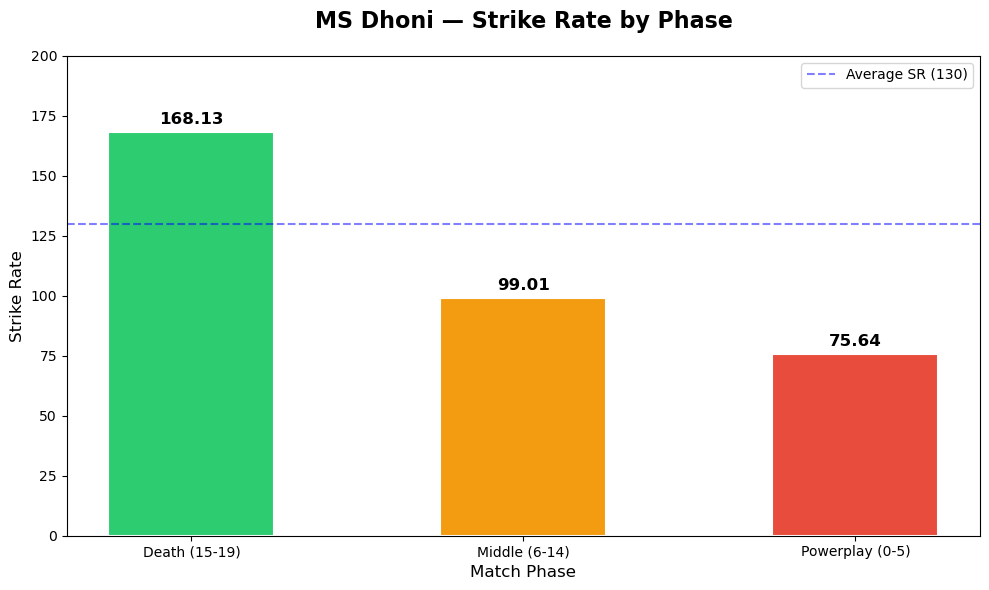

Chart saved!


In [9]:
import matplotlib.pyplot as plt

# Data for chart
phases = phase_stats['phase']
strike_rates = phase_stats['strike_rate']
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # green, orange, red

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(phases, strike_rates, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add value labels on top of each bar
for bar, val in zip(bars, strike_rates):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 2, 
             f'{val}', 
             ha='center', va='bottom', 
             fontsize=12, fontweight='bold')

# Styling
plt.title(f'{player} — Strike Rate by Phase', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Match Phase', fontsize=12)
plt.ylabel('Strike Rate', fontsize=12)
plt.ylim(0, 200)
plt.axhline(y=130, color='blue', linestyle='--', alpha=0.5, label='Average SR (130)')
plt.legend()
plt.tight_layout()
plt.savefig('dhoni_phase_strike_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [10]:
# so this is day 2 of our project , today we'll find:

# Which bowler type troubles him (pace vs spin)
# Which over range he struggles in
# Which balls he gets out most on

In [11]:
# Check dismissal types against Dhoni
dismissals_only = player_data[player_data['is_wicket'] == 1]

print(f"Total dismissals: {len(dismissals_only)}")
print(f"\nHow he gets out most:")
print(dismissals_only['dismissal_kind'].value_counts())

Total dismissals: 149

How he gets out most:
dismissal_kind
caught               92
run out              25
bowled               20
lbw                   5
caught and bowled     4
stumped               3
Name: count, dtype: int64


In [12]:
# Which bowlers dismissed Dhoni most
top_bowlers = dismissals_only['bowler'].value_counts().head(10)

print("Top 10 bowlers who dismissed Dhoni:")
print(top_bowlers)

Top 10 bowlers who dismissed Dhoni:
bowler
PP Ojha       7
Z Khan        7
CV Varun      4
JJ Bumrah     4
KA Pollard    3
A Nehra       3
YS Chahal     3
TA Boult      3
SR Watson     3
HV Patel      3
Name: count, dtype: int64


In [13]:
# Separate pace and spin bowlers manually
# We'll classify based on known bowlers in the dataset

# First let's see all bowlers who dismissed Dhoni
all_dismissal_bowlers = dismissals_only['bowler'].value_counts()
print(f"Total unique bowlers who dismissed Dhoni: {len(all_dismissal_bowlers)}")
print("\nAll bowlers:")
print(all_dismissal_bowlers)

Total unique bowlers who dismissed Dhoni: 98

All bowlers:
bowler
PP Ojha           7
Z Khan            7
CV Varun          4
JJ Bumrah         4
KA Pollard        3
                 ..
Mohammed Shami    1
MA Wood           1
MR Marsh          1
Arshdeep Singh    1
Yash Dayal        1
Name: count, Length: 98, dtype: int64


In [14]:
# List of spin bowlers who dismissed Dhoni
spin_bowlers = [
    'PP Ojha', 'CV Varun', 'YS Chahal', 'R Ashwin', 'Imran Tahir',
    'A Mishra', 'SK Raina', 'Harbhajan Singh', 'P Chawla', 'SR Watson',
    'DJ Bravo', 'SEK Agar', 'B Kumar', 'JO Holder', 'Yuvraj Singh',
    'RA Jadeja', 'SP Narine', 'KD Karthik', 'MM Patel', 'D Wiese',
    'SW Tait', 'Rashid Khan', 'SN Thakur', 'Kuldeep Yadav'
]

# Classify each dismissal as pace or spin
def classify_bowler(bowler_name):
    if bowler_name in spin_bowlers:
        return 'Spin'
    else:
        return 'Pace'

# Add bowler type column
dismissals_only = dismissals_only.copy()
dismissals_only['bowler_type'] = dismissals_only['bowler'].apply(classify_bowler)

# Count pace vs spin dismissals
bowler_type_counts = dismissals_only['bowler_type'].value_counts()

print("Dhoni dismissed by:")
print(bowler_type_counts)

total = len(dismissals_only)
pace_pct = (bowler_type_counts.get('Pace', 0) / total * 100).round(2)
spin_pct = (bowler_type_counts.get('Spin', 0) / total * 100).round(2)

print(f"\nPace: {pace_pct}%")
print(f"Spin: {spin_pct}%")

Dhoni dismissed by:
bowler_type
Pace    119
Spin     30
Name: count, dtype: int64

Pace: 79.87%
Spin: 20.13%


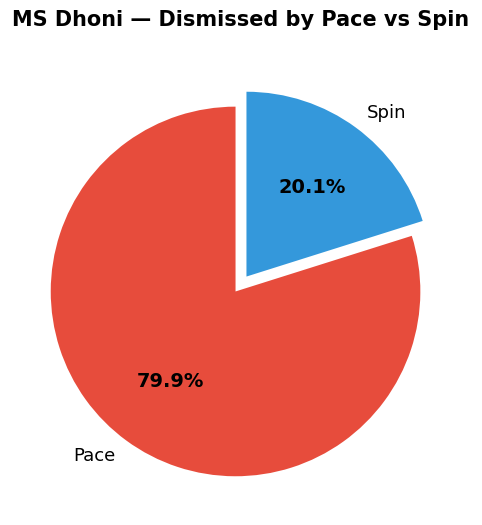

Chart saved!


In [15]:
import matplotlib.pyplot as plt

# Data
labels = ['Pace', 'Spin']
sizes = [bowler_type_counts['Pace'], bowler_type_counts['Spin']]
colors = ['#e74c3c', '#3498db']  # red for pace, blue for spin
explode = (0.05, 0.05)

# Create pie chart
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 13}
)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

plt.title(f'{player} — Dismissed by Pace vs Spin', 
          fontsize=15, fontweight='bold', pad=20)

plt.savefig('dhoni_pace_vs_spin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [16]:
# Which overs does Dhoni get dismissed most
over_dismissals = dismissals_only['over'].value_counts().sort_index()

print("Dismissals per over:")
print(over_dismissals)

Dismissals per over:
over
2      1
5      1
6      2
7      4
8      1
9      1
10     6
11     7
12     8
13     6
14     8
15    13
16    15
17    21
18    20
19    35
Name: count, dtype: int64


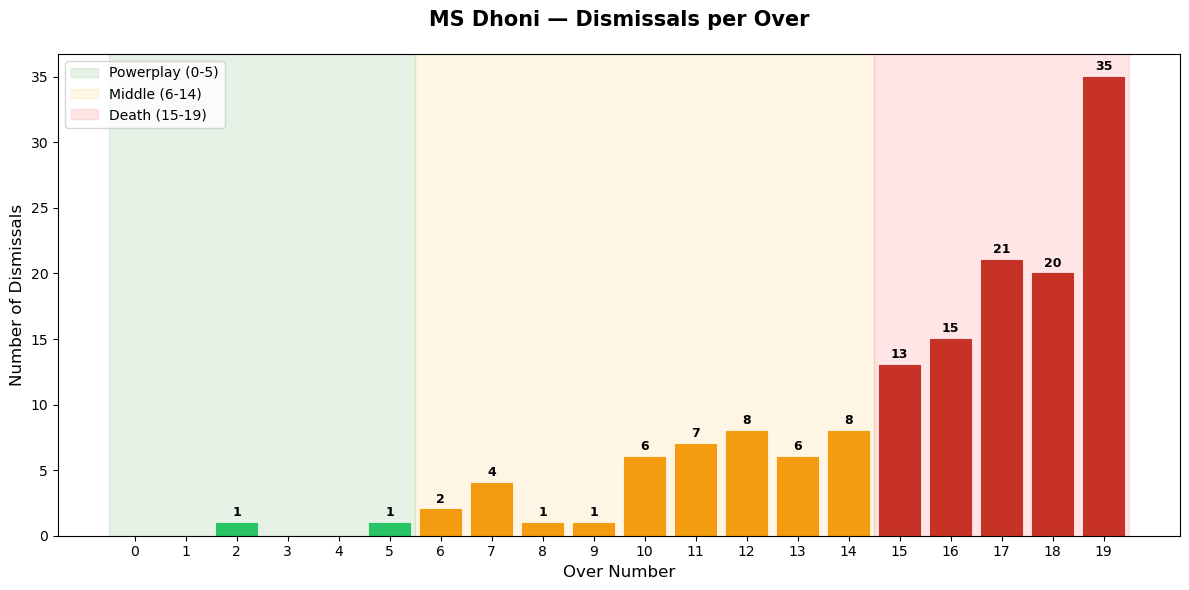

Chart saved!


In [17]:
plt.figure(figsize=(12, 6))

bars = plt.bar(over_dismissals.index, 
               over_dismissals.values,
               color='#e74c3c',
               edgecolor='white',
               linewidth=0.8)

# Highlight death overs
for i, bar in enumerate(bars):
    over_num = over_dismissals.index[i]
    if over_num >= 15:
        bar.set_color('#c0392b')  # darker red for death overs
    elif over_num <= 5:
        bar.set_color('#2ecc71')  # green for powerplay
    else:
        bar.set_color('#f39c12')  # orange for middle overs

# Add value on top of each bar
for bar, val in zip(bars, over_dismissals.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(val),
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

# Add phase labels
plt.axvspan(-0.5, 5.5, alpha=0.1, color='green', label='Powerplay (0-5)')
plt.axvspan(5.5, 14.5, alpha=0.1, color='orange', label='Middle (6-14)')
plt.axvspan(14.5, 19.5, alpha=0.1, color='red', label='Death (15-19)')

plt.title(f'{player} — Dismissals per Over', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Over Number', fontsize=12)
plt.ylabel('Number of Dismissals', fontsize=12)
plt.xticks(range(0, 20))
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dhoni_over_dismissals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")